# Housing Price Prediction — TensorFlow Regression
**Dataset:** [King County House Sales](https://www.kaggle.com/harlfoxem/housesalesprediction)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

## Load Data

In [21]:
df = pd.read_csv("kc_house_data.csv")
print(df.shape)
df.head()

(21597, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## EDA

In [22]:
print("Missing values:")
print(df.isna().sum())
print()
df.describe().T

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
id,21597.0,4.580474e+09,2.876736e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21597.0,5.402966e+05,3.673681e+05,7.800000e+04,3.220000e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21597.0,3.373200e+00,9.262989e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21597.0,2.115826e+00,7.689843e-01,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21597.0,2.080322e+03,9.181061e+02,3.700000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21597.0,1.509941e+04,4.141264e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068500e+04,1.651359e+06
floors,21597.0,1.494096e+00,5.396828e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21597.0,7.547345e-03,8.654900e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21597.0,2.342918e-01,7.663898e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21597.0,3.409825e+00,6.505456e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


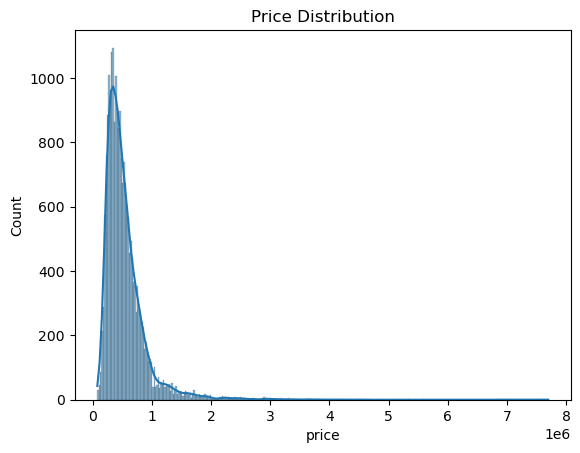

In [23]:
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

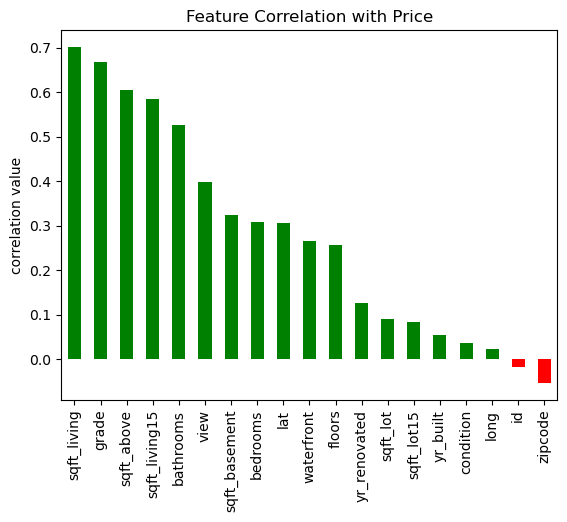

In [24]:
corr = df.corr(numeric_only=True)["price"].drop("price").sort_values(ascending=False)

corr.plot(kind="bar", color=["green" if v >= 0 else "red" for v in corr])
plt.title("Feature Correlation with Price")
plt.ylabel("correlation value")
plt.show()

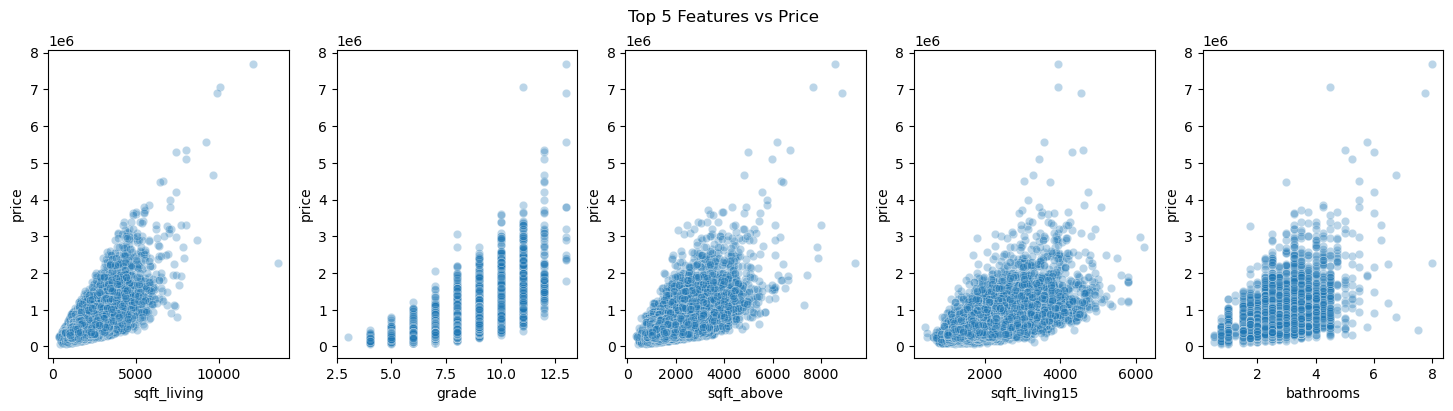

In [25]:
top_features = corr.abs().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    sns.scatterplot(data=df, x=feat, y="price", alpha=0.3, ax=ax)
plt.suptitle("Top 5 Features vs Price")
plt.show()

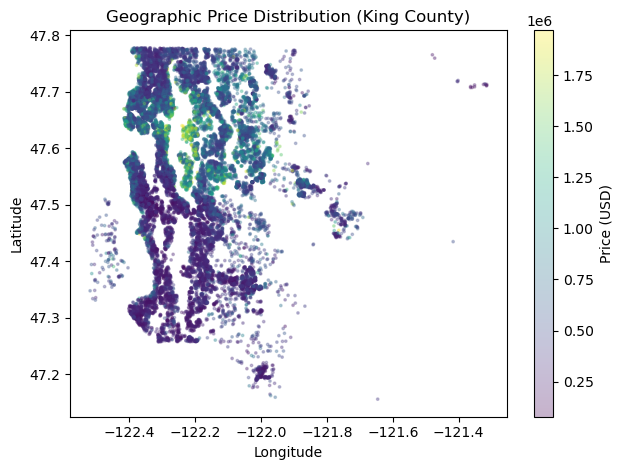

In [26]:
# Remove top 1% outliers for clearer geo visualisation
q99 = df["price"].quantile(0.99)
df_geo = df[df["price"] <= q99]


plt.scatter(df_geo["long"], df_geo["lat"], c=df_geo["price"], alpha=0.3, s=3)
plt.colorbar(label="Price (USD)")
plt.title("Geographic Price Distribution (King County)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

## Feature Engineering

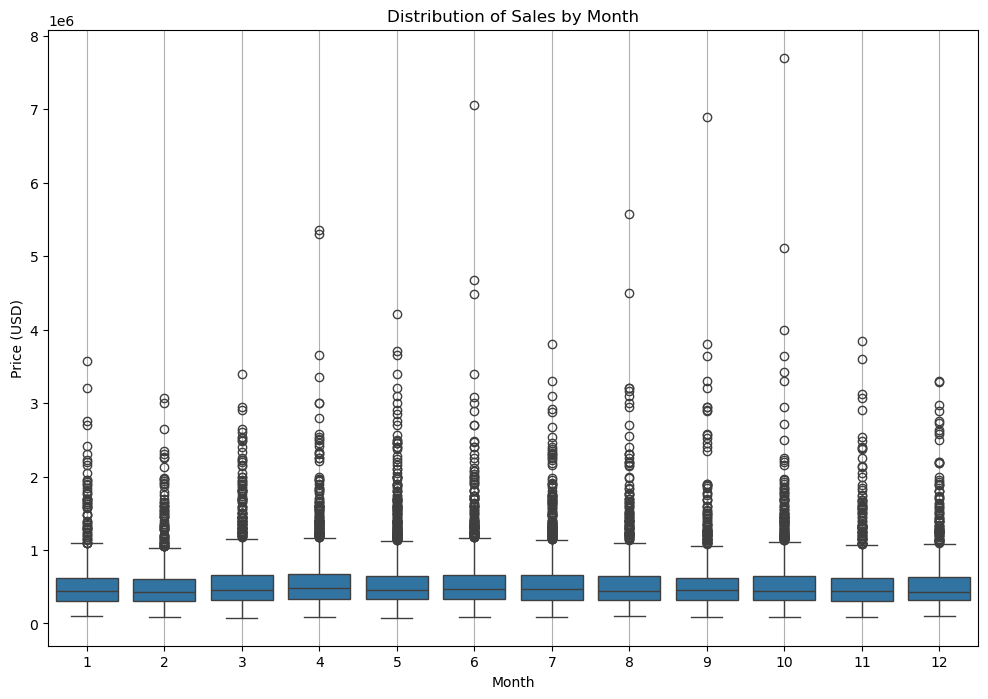

In [27]:
df["date"] = pd.to_datetime(df["date"])
df["sale_year"]  = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

# cyclical encoding months
df["month_sin"] = np.sin(2 * np.pi * df["sale_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["sale_month"] / 12)

plt.figure(figsize=(12,8))
sns.boxplot(data=df, x="sale_month", y="price")
plt.grid(axis="x")
plt.title("Distribution of Sales by Month")
plt.xlabel("Month")
plt.ylabel("Price (USD)")
plt.show()

In [28]:
drop_cols = ["id", "date", "zipcode", "sale_month"]
df = df.drop(columns=drop_cols)

pd.set_option("display.max_columns", None)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,sale_year,month_sin,month_cos
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,2014,-8.660254e-01,0.5
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,2014,-2.449294e-16,1.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2015,8.660254e-01,0.5
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,2014,-2.449294e-16,1.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2015,8.660254e-01,0.5


## Preprocessing

In [29]:
# split the data

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
# scale the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Model

In [31]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(64,  activation="relu"),
    Dense(32,  activation="relu"),
    Dense(32,  activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

d:\anaconda\anaconda\envs\keras-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,673 (33.88 KB)

 Trainable params: 8,673 (33.88 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)

In [33]:
model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=4000,
    batch_size=128,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 424922349568.0000 - val_loss: 420806426624.0000
Epoch 2/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 307576700928.0000 - val_loss: 120958377984.0000
Epoch 3/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 71951245312.0000 - val_loss: 61595844608.0000
Epoch 4/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55436206080.0000 - val_loss: 52202053632.0000
Epoch 5/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48102014976.0000 - val_loss: 45919195136.0000
Epoch 6/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 43127754752.0000 - val_loss: 41671839744.0000
Epoch 7/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39788449792.0000 - val_loss: 39060480000.0000
Epoch 8/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37685833728.0000 - val_loss: 37189525504.0000
Epoch 9/4000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36303257600.0000 - val_loss: 36091858944.0000
Epoch 10/4000
135/135 ━━

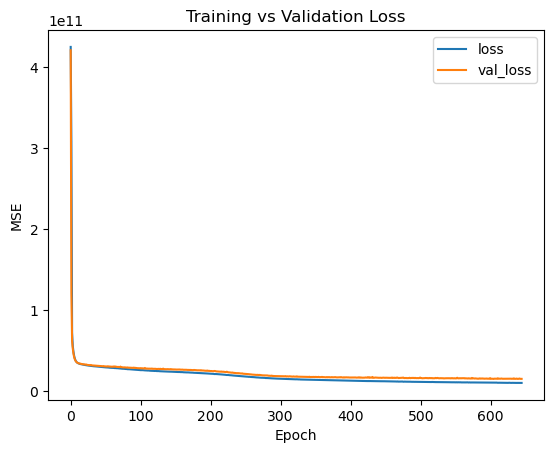

In [34]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot(title="Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

## Evaluation

In [35]:
predictions = model.predict(X_test_scaled).flatten()

mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
avg_price = y.mean()

print(f"MAE:                ${mae:,.0f}")
print(f"RMSE:               ${rmse:,.0f}")
print(f"MAE / Avg Price:    {mae / avg_price * 100:.1f}%")

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE:                $74,391
RMSE:               $122,420
MAE / Avg Price:    13.8%


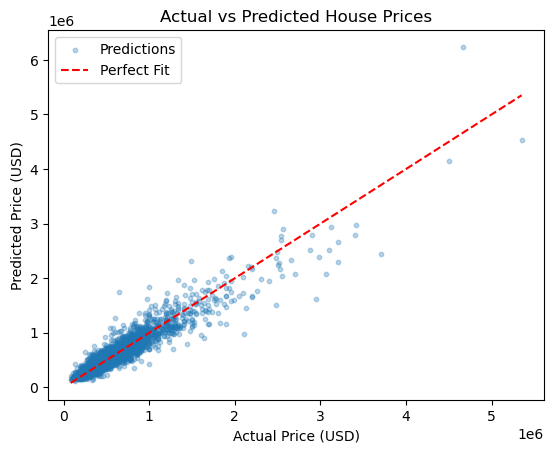

In [36]:
plt.scatter(y_test, predictions, alpha=0.3, s=10, label="Predictions")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Perfect Fit")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

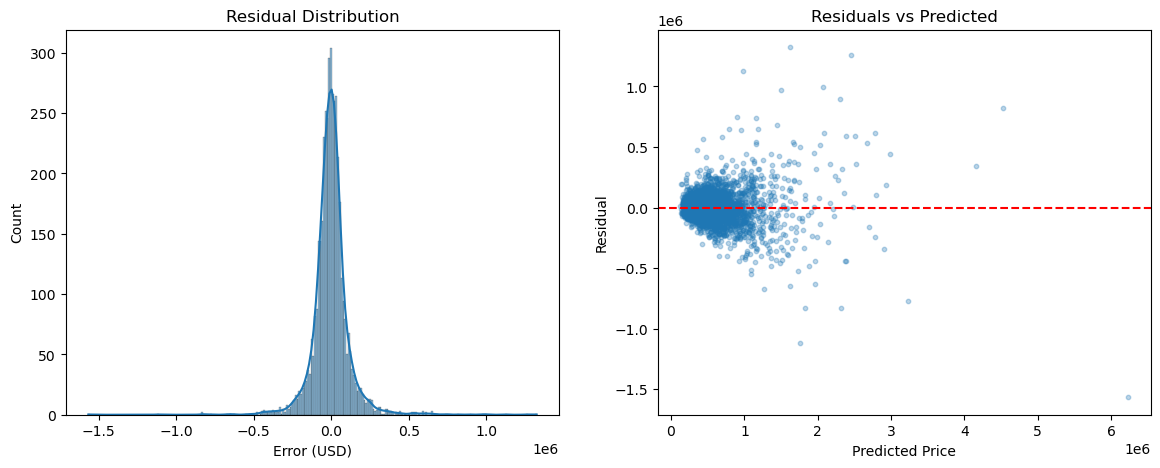

In [37]:
residuals = y_test.values - predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Error (USD)")

axes[1].scatter(predictions, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual")

plt.show()

## Prediction

In [38]:
sample = X_test.iloc[:5]
sample_scaled = scaler.transform(sample)
sample_preds  = model.predict(sample_scaled)

sample["actual_price"]    = y_test.iloc[:5]
sample["predicted_price"] = sample_preds.round(0)
sample["error_%"] = ((sample["predicted_price"] - sample["actual_price"]) / sample["actual_price"] * 100).round(1)

sample[["actual_price", "predicted_price", "error_%"]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


,actual_price,predicted_price,error_%
2497,195000.0,260878.0,33.8
18763,235000.0,270845.0,15.3
11663,244000.0,274333.0,12.4
15471,257000.0,236461.0,-8.0
6941,420000.0,431869.0,2.8
